# 4-Lobe Lightbridge Fuel

## Burnable Absorber Displacer

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('spawn')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
import pandas as pd
from igakit import cad

from ttnte.xs.benchmarks import kaist
from ttnte.cad.curves import qtrlobe
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import power, LinearSolverOptions 
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = kaist()

In [3]:
D = 1.26 # Fuel width
D2 = D*0.5
X = 1.36 # Channel pitch
delta = 0.306 # Width of lobes
y2 = delta * 0.5
d = 0.04 # Thickness of cladding at valleys
dmax = 0.102 # Thickness of cladding at ends of the lobes
R = 0.297 # Radius defining outer curve of valleys
a = 0.156 # Displacer width

y1 = y2-d # Half of width of inner lobe
x1 = (D2 - R - y2 - dmax) # Portrusion of innerlobe
x2 = x1 + dmax # Portrusion of outer lobe

In [4]:
# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
burn = cad.line(p1=(a / (2 ** 0.5), 0), p0=(0, a / (2 ** 0.5)))
fuel = qtrlobe(outrad=R + d, portrs=x1, hfwidth=y1 )
clad = qtrlobe(outrad=R, portrs=x2, hfwidth=y2 )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [5]:
# Create IGA mesh object
mesh = IGAMesh()

# Create NURBS surfaces and add them
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    osec = origin.slice(0, sections[i], sections[i + 1])
    bsec = burn.slice(0, sections[i], sections[i + 1])
    fsec = fuel.slice(0, sections[i], sections[i + 1])
    csec = clad.slice(0, sections[i], sections[i + 1])

    # Create patches
    mesh.add_patch(Patch(cad.ruled(osec, bsec), "BA (UO2 FA)"))
    mesh.add_patch(Patch(cad.ruled(bsec, fsec), "UO2 3%"))
    mesh.add_patch(Patch(cad.ruled(fsec, csec), "Guide Tube"))
    mesh.add_patch(Patch(cad.ruled(csec, edges[i]), "Water"))
    
# Refine mesh
mesh.refine(10, 2)
    
# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=12, reflective_boundaries=True)
  -> Patch(material=BA (UO2 FA), source=None, id=0, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=1, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=2, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Water, source=None, id=3, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=BA (UO2 FA), source=None, id=4, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=5, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=6, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Water, source=None, id=7, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=BA (UO2 FA), source=None, id=8, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=9, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=10, name=None, shape=(12, 12), backend=geomdl)
  -> Patch(material=Water, source=None, id=11, name=None, shape=(12, 12), backend=geomdl)

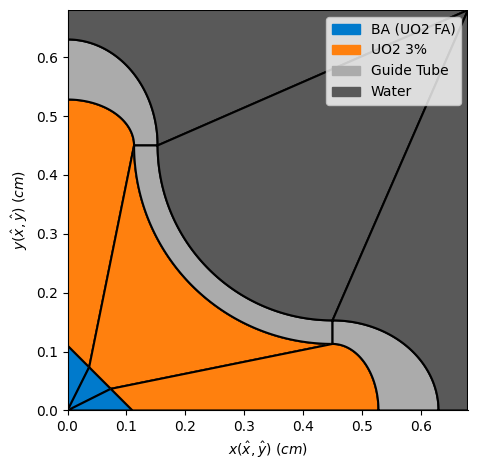

In [6]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False, plot_boundaries=True)
plt.tight_layout()
plt.savefig("./figs/four_lobe_ba.png", dpi=300, transparent=True)
plt.show()

## Assemble Matrix and TT Operators

In [7]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=2,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info_ba.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=4,
)
tts = assembler.build(use_tt=False, eps=1e-5)

# Save TT information
assembler.save_info("./tt_info_ba.csv")

Running MatrixAssembler.build()
Discretization: N = 1024, G = 7, P = 12, A = 12, B = 12
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 102.68 s)
Step            Shape                     Compression
H               12386304,12386304          298465.16
S               12386304,12386304          524282.44
F               12386304,12386304         1048575.77
B_out           12386304,12386304         5181100.90
B_in            12386304,12386304         5156191.60
Running TTAssembler.build()
Discretization: N = 1024, G = 7, P = 12, A = 12, B = 12
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 194.53 s)
Step            Ranks                     Compression
H               3,3,3,6,23,9              2714734875.97
S               3,3,2,4,9,5               9206704679.57
F               1,1,1,2,4,4               32936995873.85
B_out           4,34,85,89,47,3           86752125.56
B_in            8,38,89,93,50,4           74901650.68


## Solve

In [8]:
psi, k = power(
    T=(tts.H - tts.S).round(1e-5) + (mats.B_out - mats.B_in).combine(),
    F=tts.F,
    tol=1e-8,
    maxiter=1000,
    gpu_idx=0,
    lsoptions=LinearSolverOptions(
        tol=1e-10,
        maxiter=10,
        restart=75,
    )
)
psi = psi.reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh_ba.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Running power iteration on GPU 0


-- (0): k = 0.157434, Angular Flux L2-Error = 2.082344401118, Elapsed Time = 164.643 s


-- (1): k = 0.140606, Angular Flux L2-Error = 0.833523913319, Elapsed Time = 329.147 s


-- (2): k = 0.150405, Angular Flux L2-Error = 0.432360619541, Elapsed Time = 493.783 s


-- (3): k = 0.180275, Angular Flux L2-Error = 0.269978362676, Elapsed Time = 658.556 s


...

-- (801): k = 0.838902, Angular Flux L2-Error = 0.000000010289, Elapsed Time = 132149.786 s


-- (802): k = 0.838902, Angular Flux L2-Error = 0.000000010126, Elapsed Time = 132314.553 s


-- (803): k = 0.838902, Angular Flux L2-Error = 0.000000010019, Elapsed Time = 132479.326 s


-- (804): k = 0.838902, Angular Flux L2-Error = 0.000000009959, Elapsed Time = 132644.101 s


-- Converged!


## Plot and Compare to OpenMC

In [9]:
# Get OpenMC solution
k_mc = [0.8394194157475255, 5.56599699347134e-05]
phi_mc = np.load("./openmc/openmc_ba/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/openmc_ba/data/mesh_stdev.npy")

# Ensure OpenMC solution is normalized
phi_mc_stdev /= np.linalg.norm(phi_mc.flatten(), 2)
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print(f"TDIGA k = {k}")
print(f"OpenMC k = {k_mc[0]} +/- {k_mc[1]}")
print(f"Error = {(k - k_mc[0]) * 1e5} pcm or {(k - k_mc[0]) / k_mc[1]} stdevs from OpenMC")

TDIGA k = 0.8389020029970595
OpenMC k = 0.8394194157475255 +/- 5.56599699347134e-05
Error = -51.74127504660176 pcm or -9.295958137830816 stdevs from OpenMC


<Figure size 640x480 with 0 Axes>

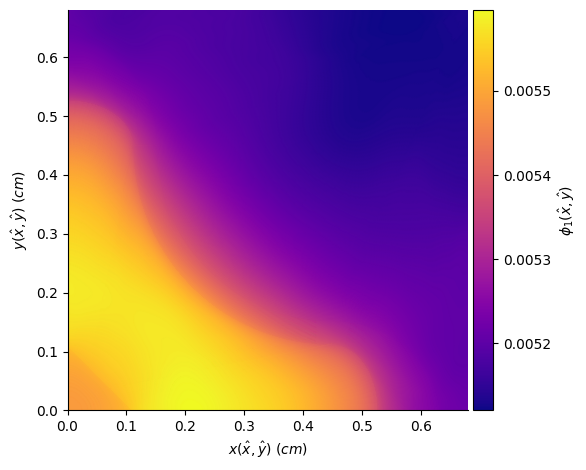

<Figure size 640x480 with 0 Axes>

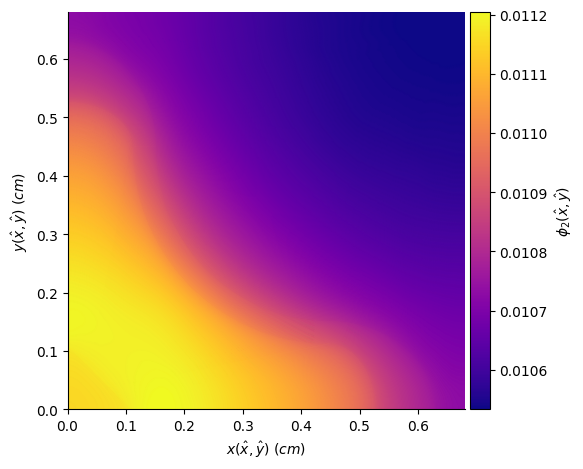

<Figure size 640x480 with 0 Axes>

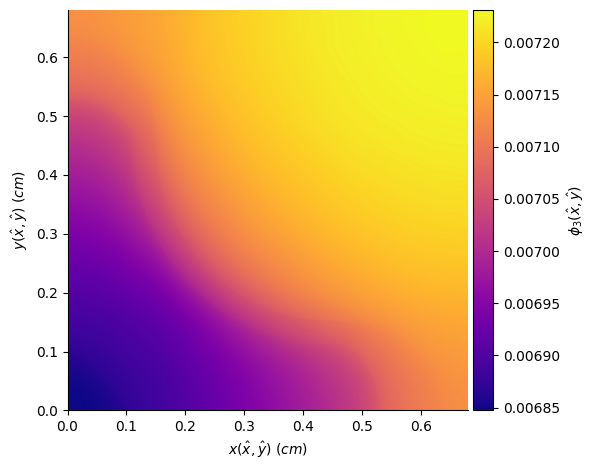

<Figure size 640x480 with 0 Axes>

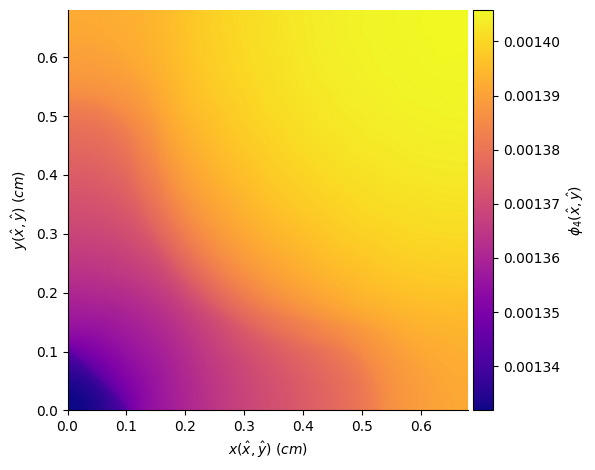

<Figure size 640x480 with 0 Axes>

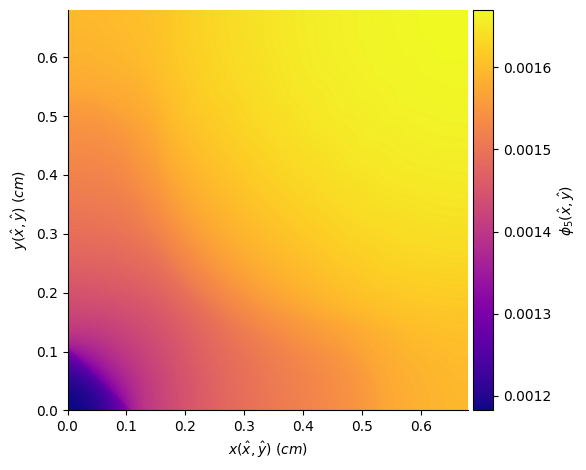

<Figure size 640x480 with 0 Axes>

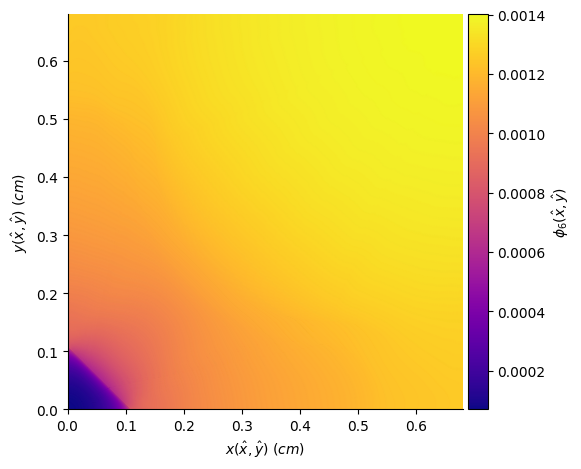

<Figure size 640x480 with 0 Axes>

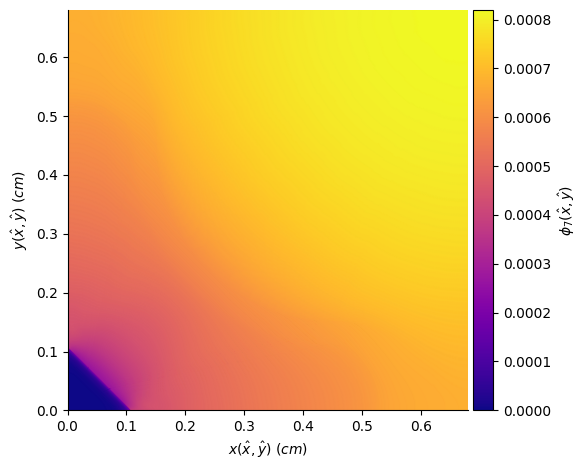

In [10]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(rf"$\phi_{g + 1}" + r"(\hat{x}, \hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_ba.png", dpi=300, transparent=True)
    plt.show()

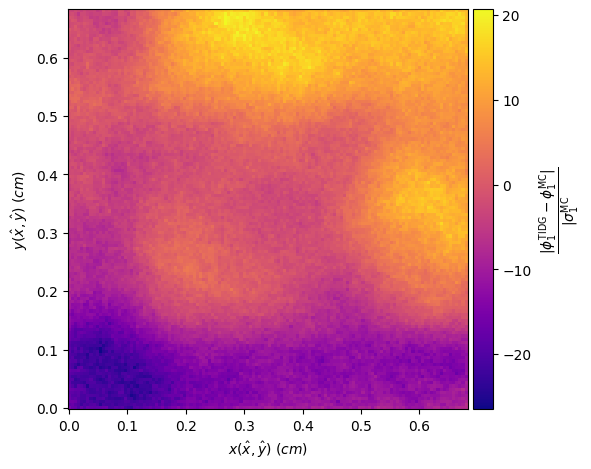

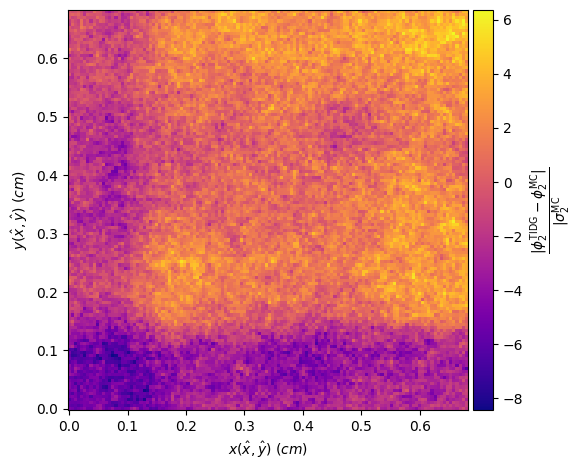

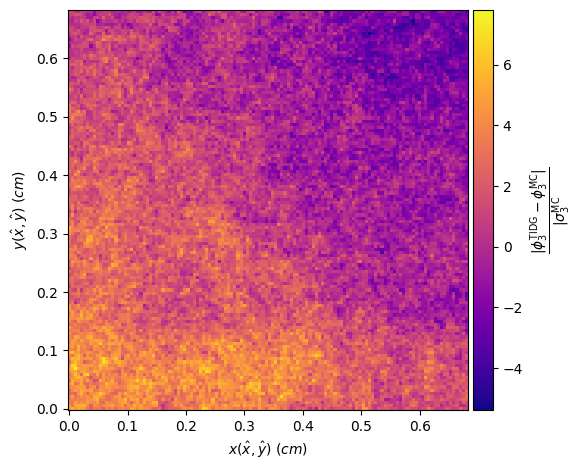

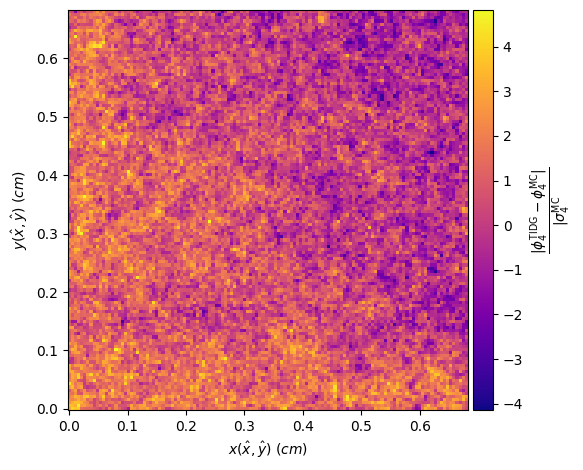

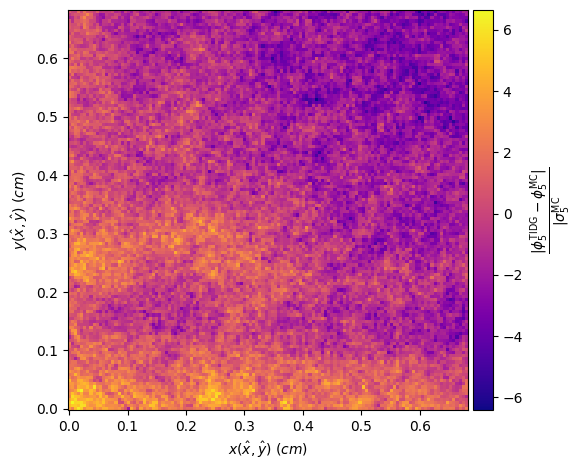

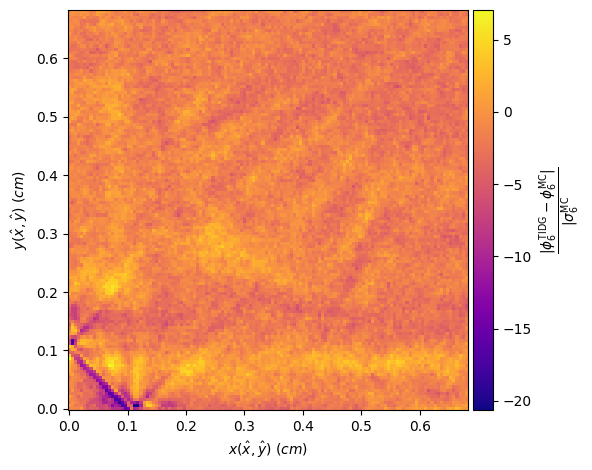

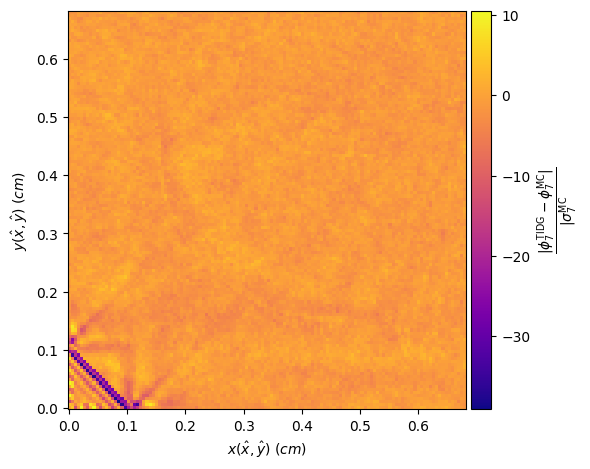

In [11]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, X / 2, phi_mc.shape[1]),
    np.linspace(0, X / 2, phi_mc.shape[2]),
)

# Calculate z-score within each voxel
z = (phi_avg - phi_mc) / phi_mc_stdev
stats = {
    "Group": list(range(1, xs_server.num_groups + 1)) + ["Total"],
    **{
        name: np.zeros(xs_server.num_groups + 1) 
        for name in 
        ["Minimum", "Q1", "Median", "Q2", "Maximum", "Mean", "L2 Error"]
    },
}

for g in range(xs_server.num_groups):    
    # Plot z-score
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, z[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        r"$\frac{|\phi^{\text{TIDG}}_{" 
        + str(g + 1) 
        + r"} - \phi^{\text{MC}}_{"
        + str(g + 1) 
        + r"}|}{|\sigma^{\text{MC}}_{"
        + str(g + 1) 
        + r"}}$", 
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_ba_zscore.png", dpi=300)
    plt.show()

    # Get some stats
    stats["Minimum"][g] = np.min(z[g,])
    stats["Q1"][g] = np.percentile(z[g,], 25)
    stats["Median"][g] = np.median(z[g,])
    stats["Q2"][g] = np.percentile(z[g,], 75)
    stats["Maximum"][g] = np.max(z[g,])
    stats["Mean"][g] = np.mean(z[g,])

stats["Minimum"][-1] = np.min(z)
stats["Q1"][-1] = np.percentile(z, 25)
stats["Median"][-1] = np.median(z)
stats["Q2"][-1] = np.percentile(z, 75)
stats["Maximum"][-1] = np.max(z)
stats["Mean"][-1] = np.mean(z)

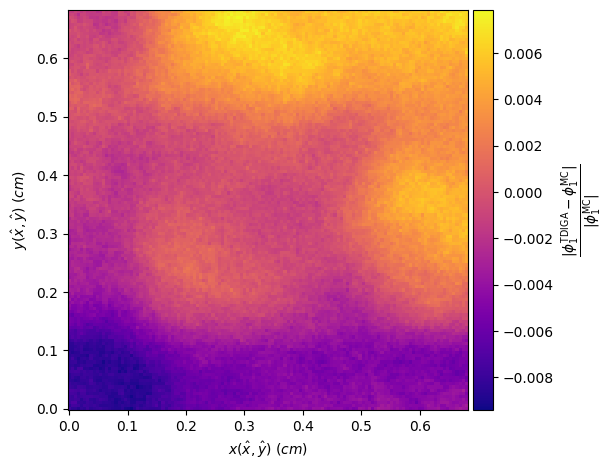

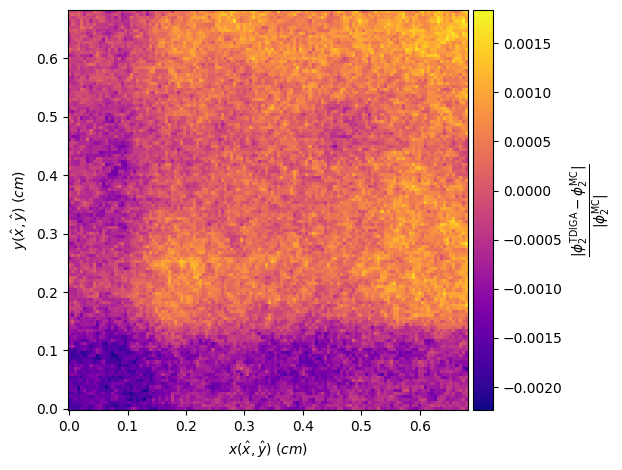

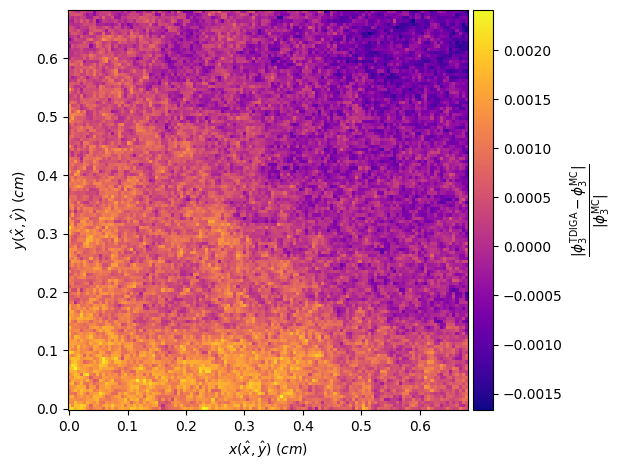

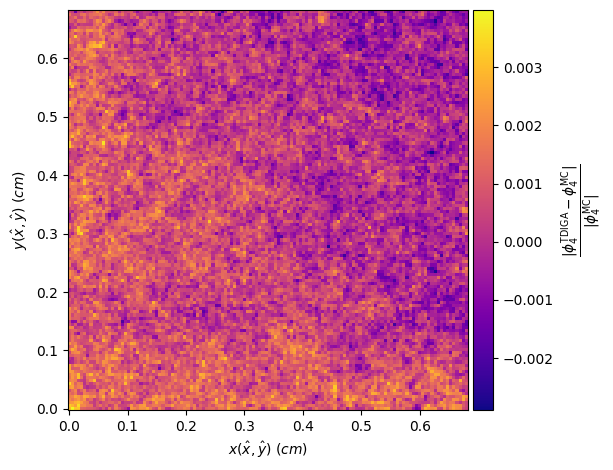

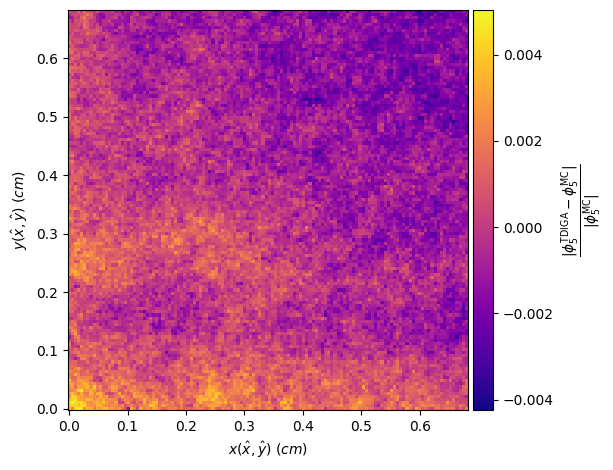

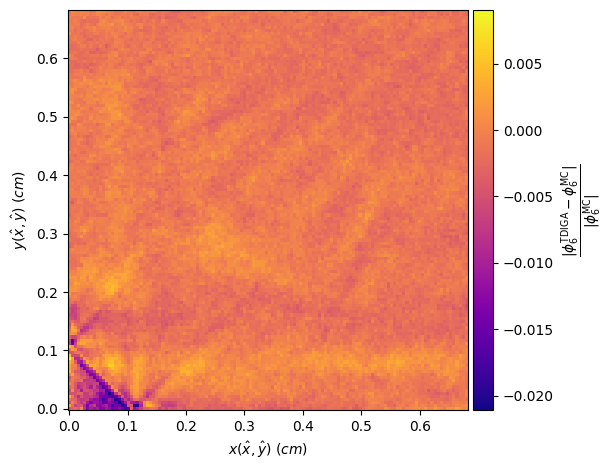

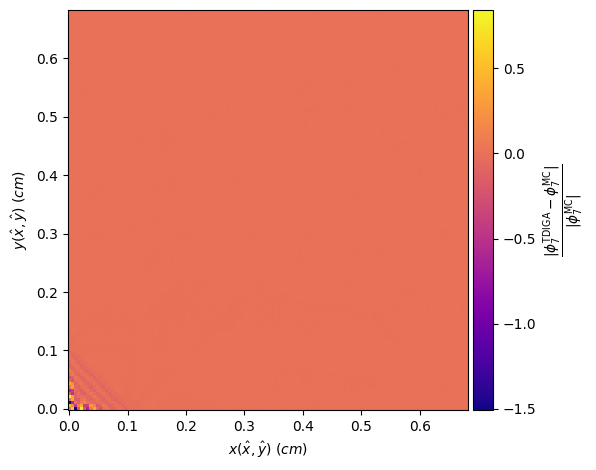

,Group,Minimum,Q1,Median,Q2,Maximum,Mean,L2 Error
0,1,-26.522748,-6.613057,-0.472915,7.120758,20.664173,-0.407432,0.003710
1,2,-8.447257,-1.777617,0.445312,1.864951,6.362489,-0.006694,0.000680
2,3,-5.395424,-0.599781,0.889813,2.380489,7.807508,0.916148,0.000717
3,4,-4.149905,-0.251799,0.570865,1.407316,4.818859,0.577337,0.000958
4,5,-6.425975,-1.737418,-0.544609,0.768637,6.643497,-0.451518,0.001247
5,6,-20.669525,-2.478053,-1.502389,-0.440944,7.044572,-1.450055,0.001647
6,7,-39.112586,-1.955231,-1.145551,-0.336272,10.524516,-1.275975,0.001854
7,Total,-39.112586,-1.769285,-0.324553,1.256388,20.664173,-0.299741,0.004834


In [12]:
relative_error = (phi_avg - phi_mc) / phi_mc

for g in range(xs_server.num_groups):
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, relative_error[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        r"$\frac{|\phi_" 
        + str(g + 1) + r"^{\text{TDIGA}} - \phi_" 
        + str(g + 1) + r"^{\text{MC}}|}{|\phi_" 
        + str(g + 1) + r"^{\text{MC}}|}$",
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_ba_error.png", dpi=300, transparent=True)
    plt.show()

    # Calculate L2-error
    stats["L2 Error"][g] = (
        np.linalg.norm((phi_avg[g,] - phi_mc[g,]).flatten(), 2) 
        / np.linalg.norm(phi_mc[g,].flatten(), 2)
    )

# Calculate L2-error
stats["L2 Error"][-1] = (
    np.linalg.norm(stats["L2 Error"][:-1], 2)
)
pd.DataFrame(stats)